In [22]:
#Importing Tools 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans


In [23]:
#Loading data
df = pd.read_csv("ecommerce_customer_features.csv")
print("Data loaded! Shapes:", df.shape)
print(df.head)


Data loaded! Shapes: (6000, 15)
<bound method NDFrame.head of                                Customer_ID  account_age_months  \
0     0520df14-712d-4c69-a0c5-95a2e7dfc1ff                  46   
1     a4013b3f-0688-4096-a194-6074be8ffec8                   3   
2     eb870f2c-ed3d-4a21-a8ac-273fae69ea4f                  29   
3     a7433451-8ea9-428a-9d80-679c6963b39f                  35   
4     43f81935-49e3-44d3-94d1-5c4715738988                  39   
...                                    ...                 ...   
5995  7e6f01d6-a7bb-429e-91d1-7c929547852b                   2   
5996  4874448f-192d-4c5a-a21b-80d02b70c0e4                  52   
5997  6a5b9ad3-7488-40e9-95b7-ad0ea7354f51                   8   
5998  3306b81f-13df-4ae9-947d-deaaf7723279                   4   
5999  48867913-4bb5-4823-87f0-dd405e3970e4                   9   

      avg_order_value  total_orders  days_since_last_purchase  \
0              164.96            12                        17   
1              

In [24]:
#Cleaning data
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
print("Cleaned! Data remaining:",len(df))

Cleaned! Data remaining: 6000


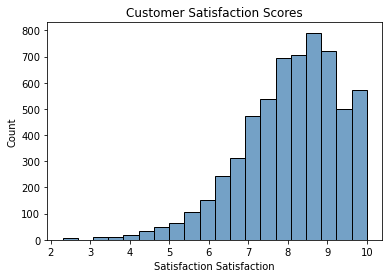

In [25]:
#Satisfaction score
sns.histplot(df['satisfaction_score'], bins=20, color='steelblue')
plt.title('Customer Satisfaction Scores')
plt.xlabel('Satisfaction Satisfaction')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

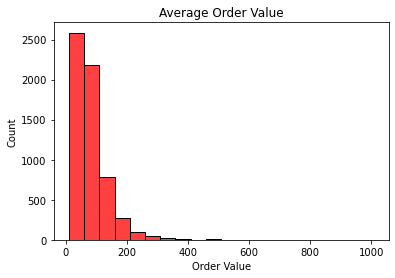

In [26]:
#Order value
sns.histplot(df['avg_order_value'], bins=20, color='red')
plt.title('Average Order Value')
plt.xlabel('Order Value')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

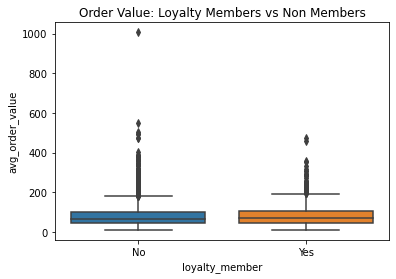

In [27]:
#Loyalty members
sns.boxplot(x='loyalty_member', y='avg_order_value', data=df)
plt.title('Order Value: Loyalty Members vs Non Members')
plt.show

In [28]:
#Insights
print("Average satisfaction score:", round(df['satisfaction_score'].mean(),1))
print("Average order value:", round(df['avg_order_value'].mean(),2))
print("Average total orders:", round(df['total_orders'].mean(),1))
print("Loyalty members %:", round((df['loyalty_member'] =='Yes').mean() * 100, 1), "%")

Average satisfaction score: 8.1
Average order value: 80.49
Average total orders: 8.6
Loyalty members %: 18.1 %


In [29]:
#Highest and Lowest order values
print("Highest order value:", np.max(df['avg_order_value']))
print("Lowest order value:", np.min(df['avg_order_value']))

Highest order value: 1006.53
Lowest order value: 10.0


In [30]:
#Customer segmentation
X = df[['avg_order_value', 'satisfaction_score']]
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['customer_group'] = kmeans.fit_predict(X)
print("Customer Groups:")
print(df['customer_group'].value_counts())
print(df.groupby('customer_group')[['avg_order_value', 'satisfaction_score']].mean())

Customer Groups:
2    3812
0    1861
1     327
Name: customer_group, dtype: int64
                avg_order_value  satisfaction_score
customer_group                                     
0                    114.690296            8.123229
1                    239.238012            7.994404
2                     50.172665            8.050060


In [31]:
#Behaviour patterns
df['spender_type'] = df['avg_order_value'].apply(
    lambda x: 'High' if x > df['avg_order_value'].mean() else 'Low'
)
print("High Spenders:", df[df['spender_type'] == 'High'].shape[0])
print("Low Spenders:", df[df['spender_type'] == 'Low'].shape[0])


High Spenders: 2272
Low Spenders: 3728


In [32]:
#Churn risk
df['churn_risk'] = ((df['satisfaction_score'] < 5) &
                     (df['days_since_last_purchase'] > 30)).astype(int)
print("At-risk customers:", df['churn_risk'].sum())

At-risk customers: 44


In [33]:
#Business report
print("Total Customers    :", len(df))
print("Avg Satisfaction   :", round(df['satisfaction_score'].mean(), 1))
print("Avg Order Value    :", round(df['avg_order_value'].mean(), 2))
print("High Spenders      :", df[df['spender_type'] == 'High'].shape[0])
print("Low Spenders       :", df[df['spender_type'] == 'Low'].shape[0])
print("At-risk Customers  :", df['churn_risk'].sum())
print("\nRecommendations:")
print("1. Send offers to at-risk customers")
print("2. Reward high spenders with loyalty perks")
print("3. Investigate low satisfaction scores")

Total Customers    : 6000
Avg Satisfaction   : 8.1
Avg Order Value    : 80.49
High Spenders      : 2272
Low Spenders       : 3728
At-risk Customers  : 44

Recommendations:
1. Send offers to at-risk customers
2. Reward high spenders with loyalty perks
3. Investigate low satisfaction scores
